# Optimizador de Prescripción Médica
## Análisis Exploratorio de Datos (EDA)
**Autor:** Pablo Foix  
**Dataset:** Clasificación de tratamientos farmacéuticos según perfil del paciente

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Carga de datos

In [4]:
df = pd.read_csv('data/drugs_classif.csv')

print('Forma del dataset:', df.shape)
display(df.head())

Forma del dataset: (200, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [5]:
print('Info del dataset:')
print(df.info())

print('\nResumen estadístico:')
display(df.describe().T)

Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB
None

Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
Age,200.0,44.315000,16.544315,15.000,31.0000,45.0000,58.00,74.000
Na_to_K,200.0,16.084485,7.223956,6.269,10.4455,13.9365,19.38,38.247


In [6]:
print('Valores nulos por columna:')
print(df.isnull().sum())

columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print('\nColumnas numéricas:', columnas_numericas)
print('Columnas categóricas:', columnas_categoricas)

Valores nulos por columna:
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

Columnas numéricas: ['Age', 'Na_to_K']
Columnas categóricas: ['Sex', 'BP', 'Cholesterol', 'Drug']


## 2. Variable objetivo: Drug

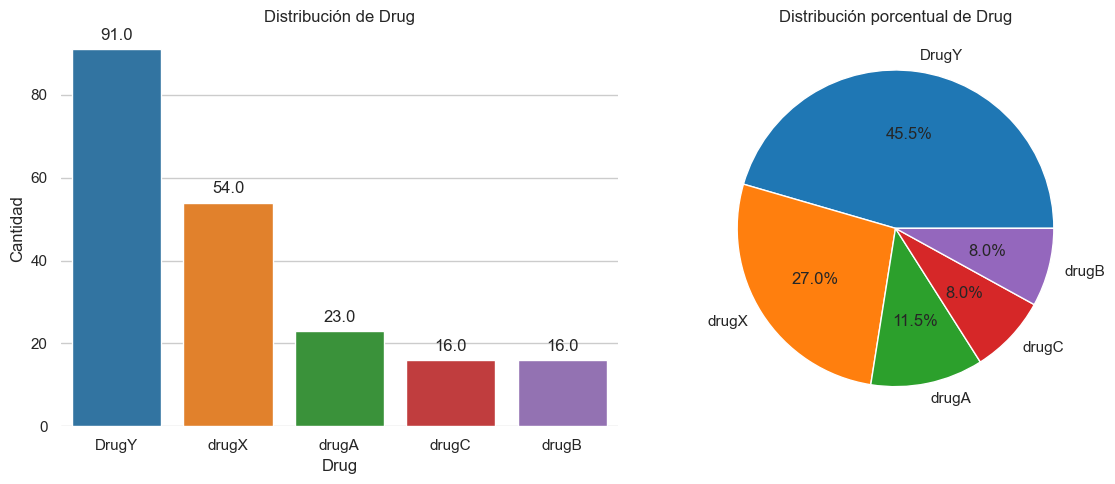

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

conteo_drogas = df['Drug'].value_counts()

sns.barplot(x=conteo_drogas.index, y=conteo_drogas, ax=axes[0], palette='tab10')
axes[0].set_title('Distribución de Drug')
axes[0].set_ylabel('Cantidad')
axes[0].set_xlabel('Drug')

for p in axes[0].patches:
    axes[0].annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='center',
        xytext=(0, 10), textcoords='offset points'
    )

sns.despine(left=True, bottom=True)

porcentaje_drogas = conteo_drogas / conteo_drogas.sum() * 100
axes[1].pie(
    porcentaje_drogas,
    labels=porcentaje_drogas.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('tab10')
)
axes[1].set_title('Distribución porcentual de Drug')

plt.tight_layout()
plt.show()

## 3. Variables numéricas

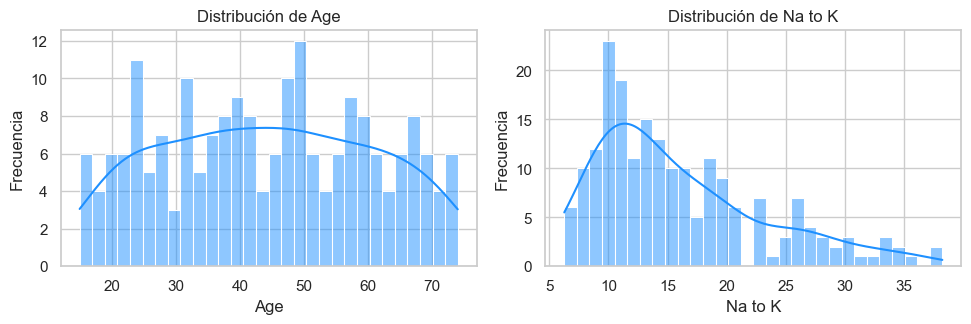

In [8]:
plt.figure(figsize=(10, 12))
for i, columna in enumerate(columnas_numericas, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[columna], kde=True, bins=30, color='dodgerblue')
    plt.title(f'Distribución de {columna.replace("_", " ")}')
    plt.xlabel(columna.replace('_', ' '))
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

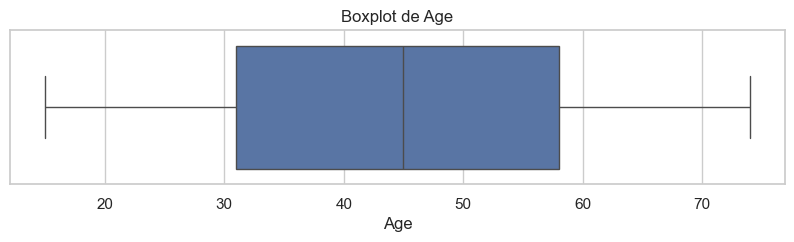

,count,mean,std,min,25%,50%,75%,max
Age,200.0,44.315,16.544315,15.0,31.0,45.0,58.0,74.0


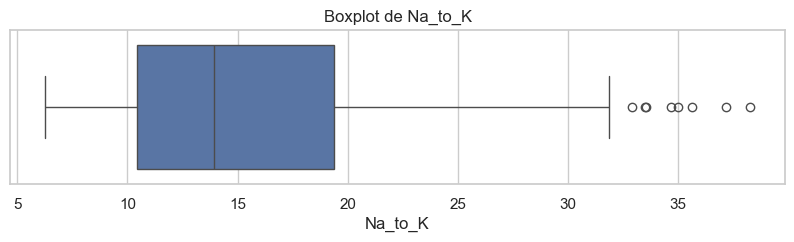

,count,mean,std,min,25%,50%,75%,max
Na_to_K,200.0,16.084485,7.223956,6.269,10.4455,13.9365,19.38,38.247


In [9]:
for col in columnas_numericas:
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()
    display(df[col].describe().to_frame().T)

## 4. Outliers

In [10]:
def detectar_outliers(data, col):
    """Detecta outliers usando el método IQR."""
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return data[(data[col] < limite_inferior) | (data[col] > limite_superior)]

for col in columnas_numericas:
    outliers = detectar_outliers(df, col)
    print(f'Outliers en {col}: {outliers.shape[0]} encontrados')

Outliers en Age: 0 encontrados
Outliers en Na_to_K: 8 encontrados


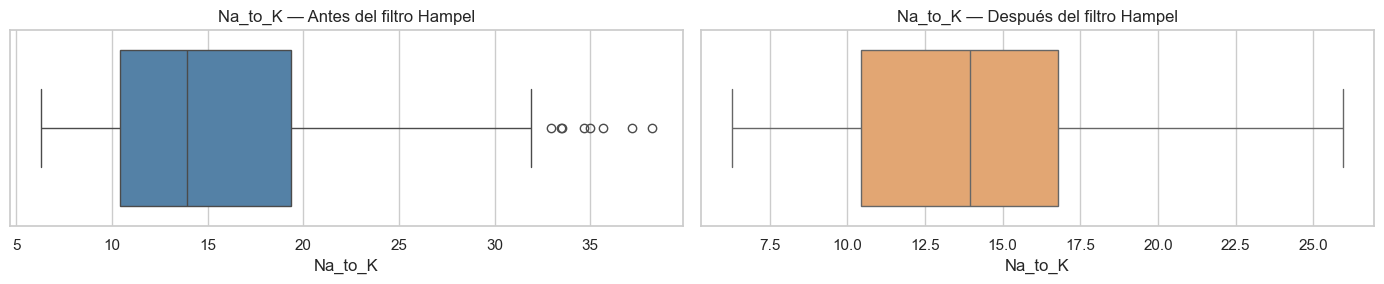

In [11]:
def filtro_hampel(data, umbral=3):
    """Reemplaza outliers por la mediana usando el filtro de Hampel."""
    mediana = np.median(data)
    mad = np.median([np.abs(x - mediana) for x in data])
    limite = umbral * mad
    return [x if np.abs(x - mediana) <= limite else mediana for x in data]

df_plot = df.copy()
df_plot['Na_to_K'] = filtro_hampel(df_plot['Na_to_K'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
sns.boxplot(x=df['Na_to_K'], ax=axes[0], color='steelblue')
axes[0].set_title('Na_to_K — Antes del filtro Hampel')
sns.boxplot(x=df_plot['Na_to_K'], ax=axes[1], color='sandybrown')
axes[1].set_title('Na_to_K — Después del filtro Hampel')
plt.tight_layout()
plt.show()

## 5. Variables categóricas

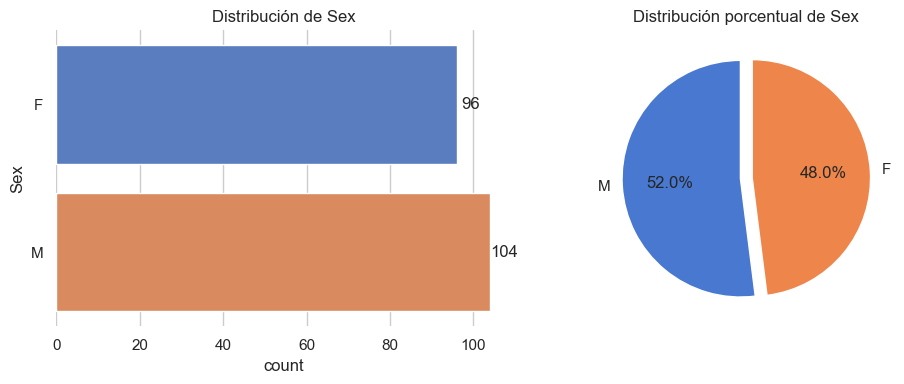

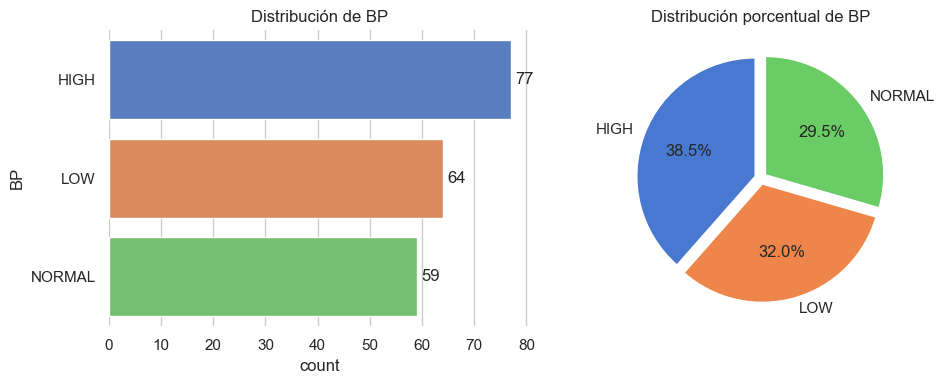

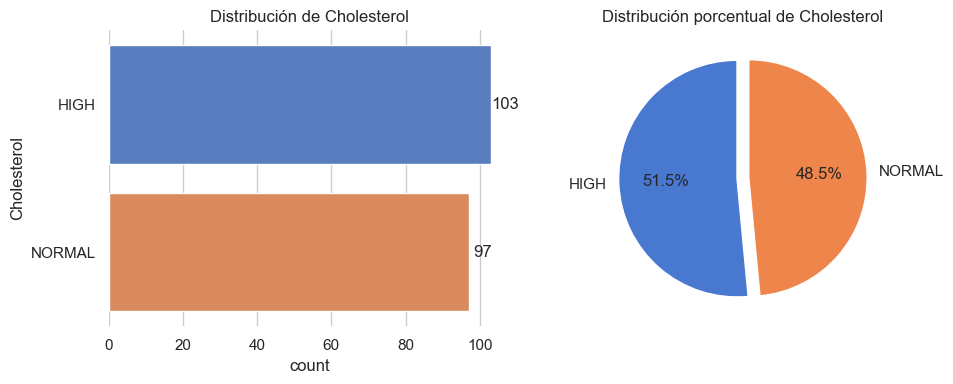

In [12]:
def graficar_distribucion_categorica(columna, data):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.countplot(y=columna, data=data, palette='muted')
    plt.title(f'Distribución de {columna}')
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_width())}',
            (p.get_width(), p.get_y() + p.get_height() / 2),
            ha='center', va='center',
            xytext=(10, 0), textcoords='offset points'
        )
    sns.despine(left=True, bottom=True)

    plt.subplot(1, 2, 2)
    data[columna].value_counts().plot.pie(
        autopct='%1.1f%%',
        colors=sns.color_palette('muted'),
        startangle=90,
        explode=[0.05] * data[columna].nunique()
    )
    plt.title(f'Distribución porcentual de {columna}')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

for col in columnas_categoricas:
    if col != 'Drug':
        graficar_distribucion_categorica(col, df)

## 6. Relación entre variables y la clase objetivo

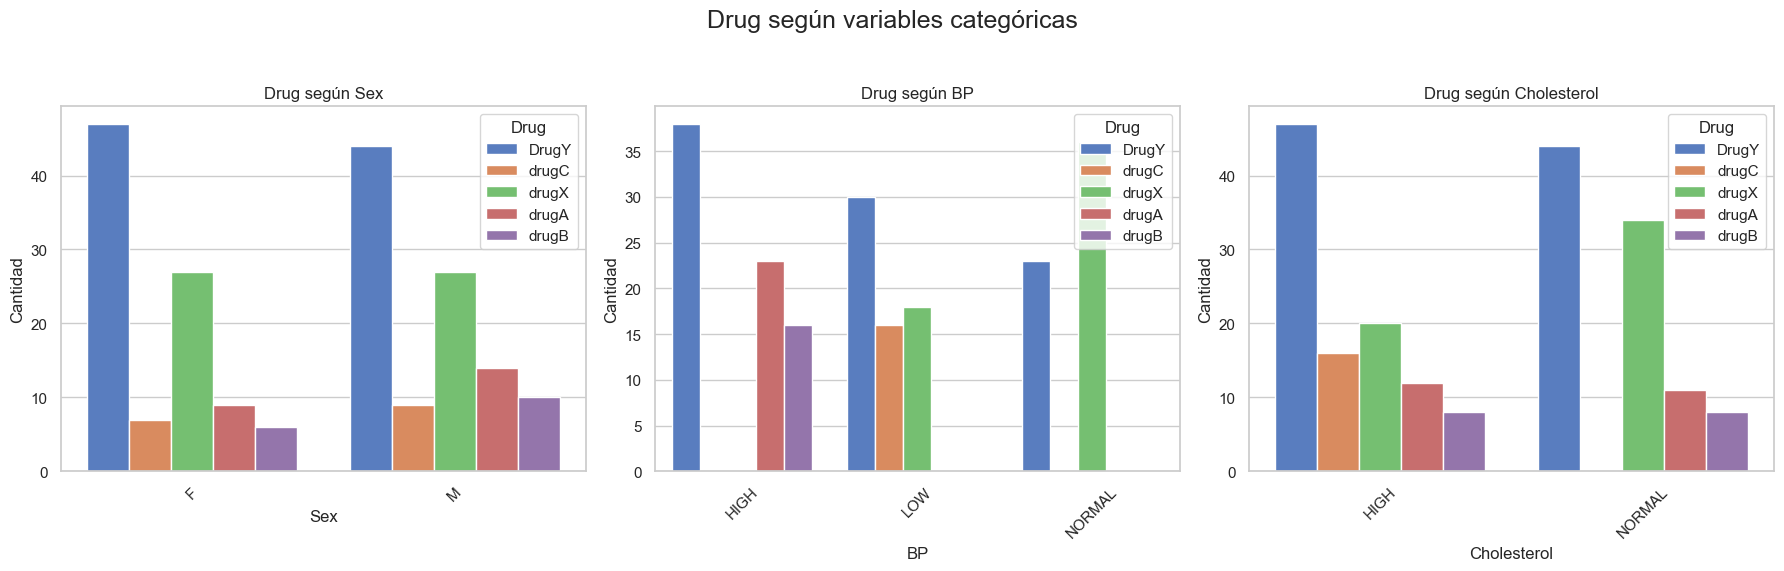

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Drug según variables categóricas', fontsize=18)

for ax, col in zip(axes, ['Sex', 'BP', 'Cholesterol']):
    sns.countplot(data=df, x=col, hue='Drug', ax=ax, palette='muted')
    ax.set_title(f'Drug según {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Cantidad')
    ax.legend(title='Drug')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

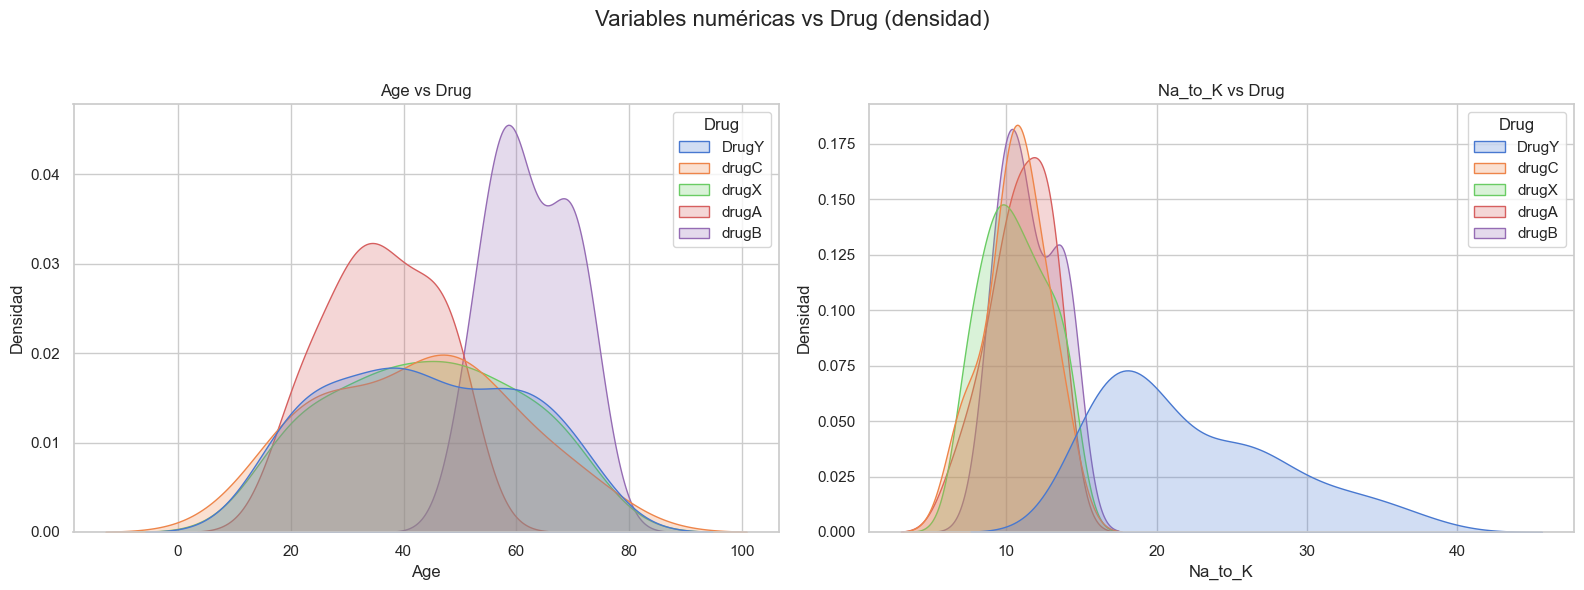

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Variables numéricas vs Drug (densidad)', fontsize=16)

for i, col in enumerate(columnas_numericas):
    sns.kdeplot(data=df, x=col, hue='Drug', ax=axes[i], fill=True, common_norm=False, palette='muted')
    axes[i].set_title(f'{col} vs Drug')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 7. Matriz de correlación

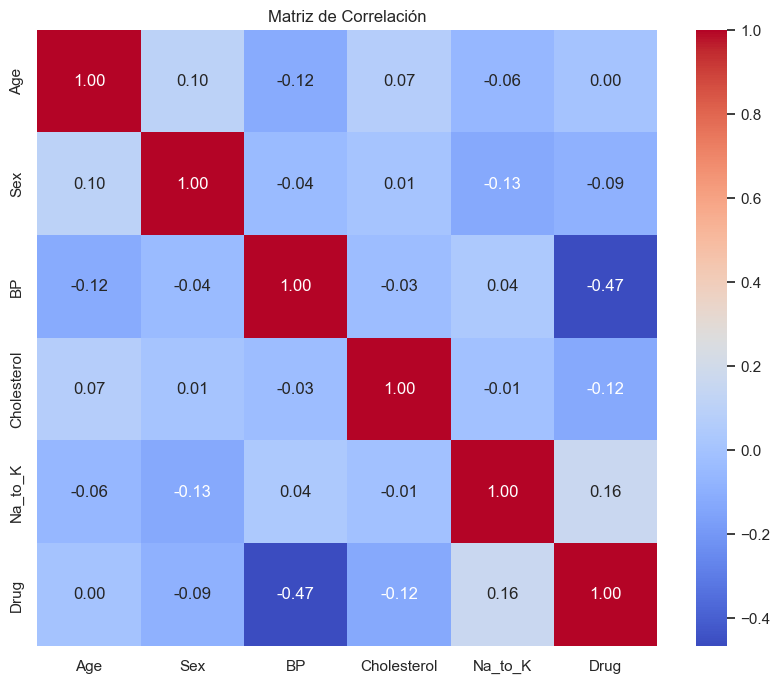

In [15]:
df_encoded = df.copy()
df_encoded['Sex']         = df_encoded['Sex'].map({'F': 0, 'M': 1})
df_encoded['Cholesterol'] = df_encoded['Cholesterol'].map({'NORMAL': 0, 'HIGH': 1})
df_encoded['BP']          = df_encoded['BP'].map({'LOW': 1, 'NORMAL': 2, 'HIGH': 3})
df_encoded['Drug']        = df_encoded['Drug'].map({'drugA': 1, 'drugB': 2, 'drugC': 3, 'DrugY': 4, 'drugX': 5})

corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

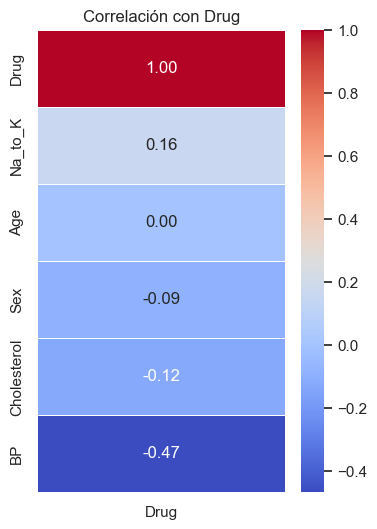

In [16]:
target_corr = corr_matrix[['Drug']].sort_values(by='Drug', ascending=False)

plt.figure(figsize=(4, 6))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlación con Drug')
plt.show()